In [5]:
import pandas as pd
df=pd.read_csv("Bank Customer Churn Prediction.csv")

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.shape

(10000, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [ ]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Insights:


1.Churn rate = 20%

2.Product number lies b/w 1 to 4, mean =1.5

3.70% of the customers have a credit card

4.50% are active members

5.Tenure 0 to 10 years

6.Age lies from 18 to 92

7.Credit score lies between 350 to 850












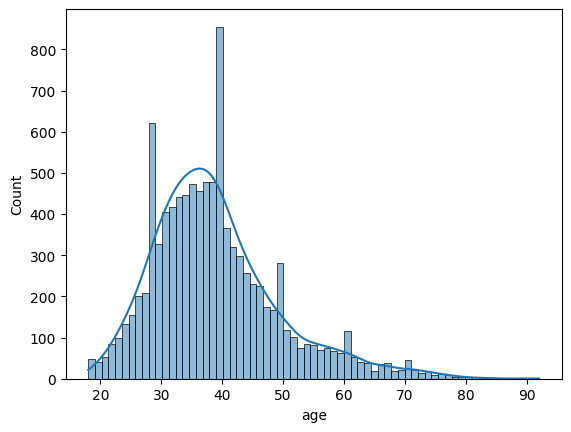

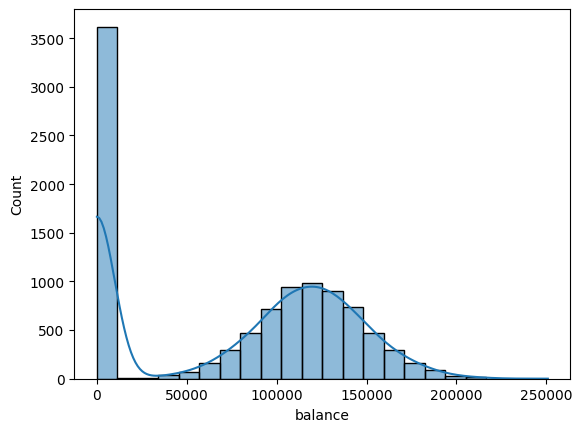

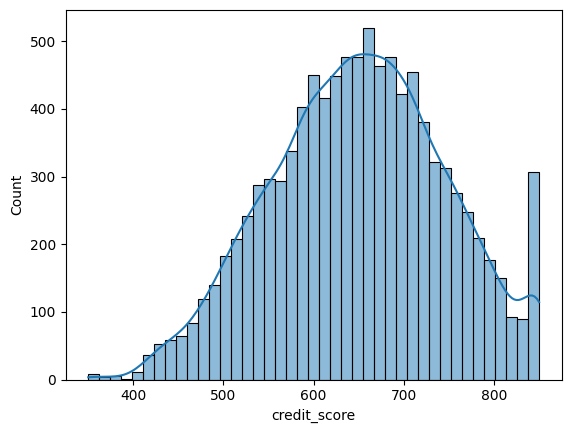

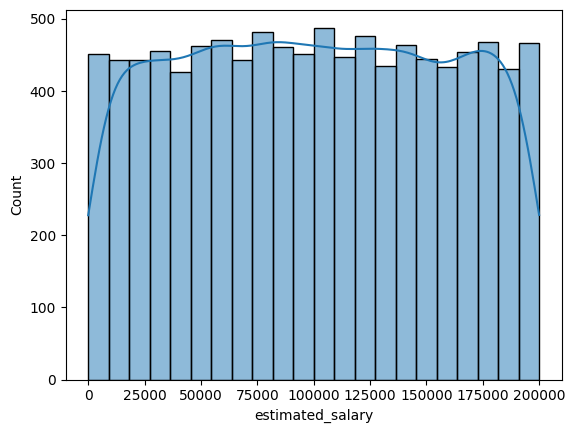

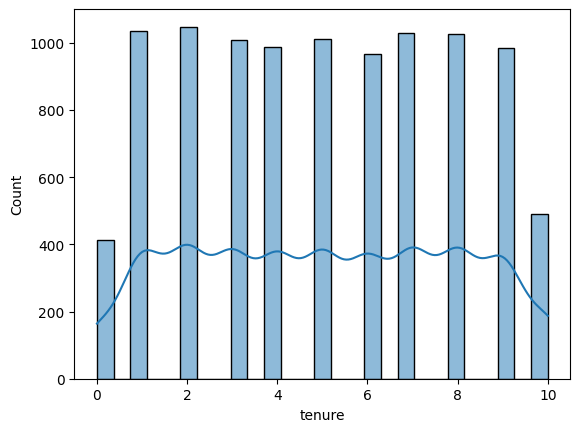

In [ ]:
measures=['age','balance','credit_score','estimated_salary','tenure']
for col in measures:
  sns.histplot(df[col], kde=True)
  plt.show()

1. Age: right skewed distribution, can target and identify causes of churn age-group wise

2. Balance: Many customers have zero balance, excluding that, its roughly normally distributed

3. Credit score: roughly normal, limit is likely to be 850

4. Estimated salary: Roughly Uniform, could be grouped with dimensions if needed

5. Tenure:Roughly Uniform, could be grouped with dimensions if needed


In [ ]:
pd.crosstab(df['active_member'], df['churn'], normalize=True)

churn,0,1
active_member,,
0,0.3547,0.1302
1,0.4416,0.0735


Observed: Higher churn proportion among inactive members (~13%) compared to active members,i.e. ~7%.

Indicating: Customer engagement strongly reduces churn probability

Hence recommending: Increase engagement via app usage, transactions, notifications, loyalty programs

In [ ]:
pd.crosstab(df['products_number'], df['churn'], normalize='index')

churn,0,1
products_number,,
1,0.722856,0.277144
2,0.924183,0.075817
3,0.172932,0.827068
4,0.000000,1.000000


Observed: Customers with 1 product show moderate churn proportion, while customers with 2 products show lowest churn. But there is a spike in churn as number of products cross 2.

Indicating: Moderate product adoption (2 products) improves retention, but higher number of products (3–4) may again increase churn (possible dissatisfaction/complexity)

Hence recommending:
Cross-sell customers from 1 → 2 products
Investigate why 3+ product users churn (over-selling? poor experience?)

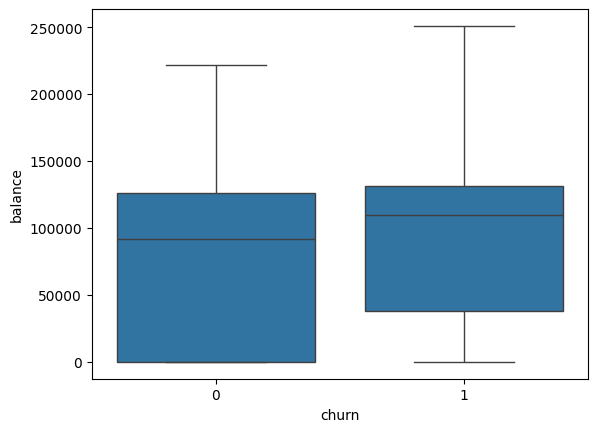

In [ ]:
sns.boxplot(x='churn',y='balance',data=df)
plt.show()

Observed: Churned customers tend to have slightly higher median balances, while many non-churned customers have zero balance

Indicating: Balance alone is not a strong predictor; zero-balance customers distort interpretation

Hence recommending:
Segment customers: zero vs non-zero balance
Analyze churn separately for both groups

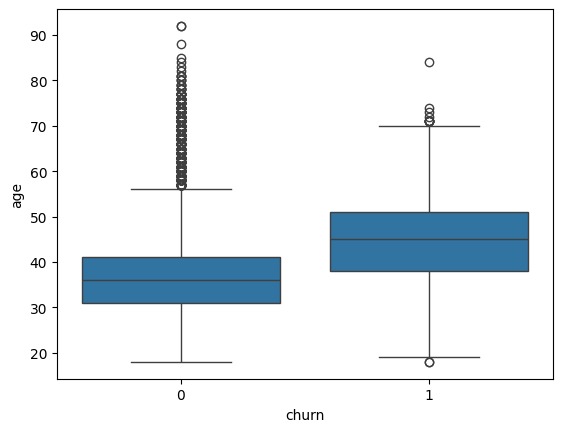

In [ ]:
sns.boxplot(x='churn', y='age', data=df)
plt.show()

Observed: Median age of churned customers is higher than non-churned customers

Indicating: Older customers are more likely to churn compared to younger customers

Hence recommending:
Target retention strategies for older customers
Provide personalized financial products / relationship management

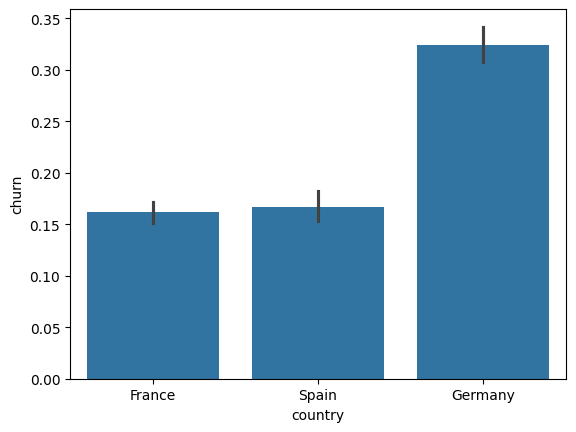

In [ ]:
sns.barplot(x='country', y='churn', data=df)
plt.show()

Observed: Customers from Germany show significantly higher churn rate compared to France and Spain

Indicating: Possible regional dissatisfaction or competitive pressure
Hence recommending:

Investigate Germany-specific issues (pricing, service, competitors)
Launch targeted retention campaigns in Germany

In [ ]:
pd.crosstab(df['credit_card'], df['churn'], normalize='index')

churn,0,1
credit_card,,
0,0.791851,0.208149
1,0.798157,0.201843


Observed: Minimal difference in churn between groups

Indicating: Credit card status has negligible impact

Hence recommending: Ignore or deprioritize this variable unless combined with others

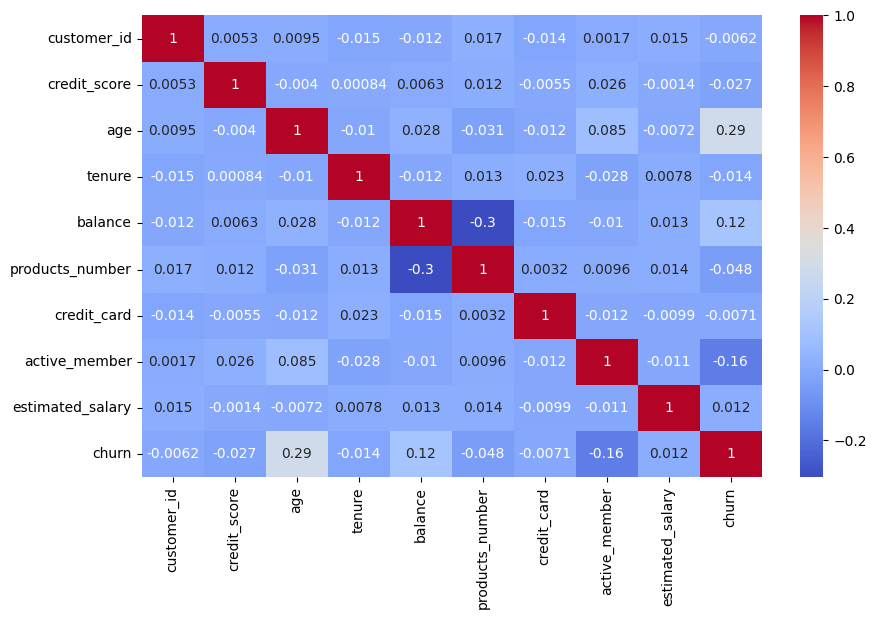

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Significant correlation with churn is shown by *age,balance,active_member*.

*Product_number* and *credit_score* could also be combined with relevant columns to identify possible reasons of churning.


In [ ]:
df.groupby(['products_number', 'active_member'])['churn'].mean()

products_number  active_member
1                0                0.366521
                 1                0.189231
2                0                0.098881
                 1                0.055601
3                0                0.882353
                 1                0.752212
4                0                1.000000
                 1                1.000000
Name: churn, dtype: float64

Observed:
Churn decreases from 1 → 2 products
Active members always have lower churn than inactive
Very high churn for 3 and 4 products

Indicating:
Having 2 products is associated with lowest churn
Active membership consistently reduces churn
Extreme churn values for 3+ products may be due to low sample size

Hence recommending:
Get more data for 3+ products so that it could be validated.

In [ ]:
df.groupby(['products_number', 'active_member'])['churn'].agg(['mean','count'])

mean  count
products_number active_member                 
1               0              0.366521   2521
                1              0.189231   2563
2               0              0.098881   2144
                1              0.055601   2446
3               0              0.882353    153
                1              0.752212    113
4               0              1.000000     31
                1              1.000000     29

Churn appears extremely high for customers with 3 or more products, these insights are not reliable due to small sample sizes and should not be used for decision-making

In [44]:
df.groupby(['active_member', pd.cut(df['age'], bins=[18,30,45,60,100])])['churn'].agg(['mean','count'])

/tmp/ipykernel_9002/2217345226.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['active_member', pd.cut(df['age'], bins=[18,30,45,60,100])])['churn'].agg(['mean','count'])


mean  count
active_member age                       
0             (18, 30]   0.101784    953
              (30, 45]   0.197277   3011
              (45, 60]   0.683609    787
              (60, 100]  0.820225     89
1             (18, 30]   0.049345    993
              (30, 45]   0.116151   2910
              (45, 60]   0.353488    860
              (60, 100]  0.112000    375

Observed:
Churn increases with age for inactive members
Active members have lower churn in every age group
Big drop in churn for active vs inactive in older groups due to older groups

Indicating:
Age effect exists, but activity modifies it strongly
Being active reduces churn across all age segments

Hence Recommended: Key focus on increasing engagement across all age groups. Churn appears very low for customers in (60,80] age bin, but these insights are not reliable due to small sample sizes and should not be used for decision-making

In [ ]:
df.groupby(pd.qcut(df['estimated_salary'], 5))['churn'].mean()

/tmp/ipykernel_162/2658557425.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['estimated_salary'], 5))['churn'].mean()


,churn
estimated_salary,
"(11.579, 41818.154]",0.242756
"(41818.154, 80414.646]",0.231975
"(80414.646, 120377.52]",0.240407
"(120377.52, 160494.082]",0.239028
"(160494.082, 199970.74]",0.249804


In [ ]:
df.groupby(pd.qcut(df['credit_score'], 5))['churn'].mean()

/tmp/ipykernel_162/3819172161.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['credit_score'], 5))['churn'].mean()


,churn
credit_score,
"(349.999, 567.0]",0.265686
"(567.0, 628.0]",0.245696
"(628.0, 678.0]",0.237315
"(678.0, 736.0]",0.216388
"(736.0, 850.0]",0.238245


In [ ]:
df.groupby(['country', 'active_member'])['churn'].mean()

country  active_member
France   0                0.211308
         1                0.115014
Germany  0                0.410785
         1                0.237179
Spain    0                0.233476
         1                0.107470
Name: churn, dtype: float64

Observed:
Germany has highest churn in both active & inactive
Active members always have lower churn than inactive

Indicating:
Country differences exist
Activity reduces churn consistently across countries

Hence recommending:
Germany needs deeper investigation
Activity is a stable protective factor

In [ ]:
df['credit_segment'] = pd.qcut(df['credit_score'], q=3, labels=['low','mid','high'])

df.groupby(['credit_segment', 'products_number'])['churn'].mean()

/tmp/ipykernel_5007/815864689.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['credit_segment', 'products_number'])['churn'].mean()


credit_segment  products_number
low             1                  0.289094
                2                  0.082129
                3                  0.890110
                4                  1.000000
mid             1                  0.268709
                2                  0.071522
                3                  0.786517
                4                  1.000000
high            1                  0.273277
                2                  0.073834
                3                  0.802326
                4                  1.000000
Name: churn, dtype: float64

Observed: Across all credit segments, churn drops significantly from ~27–29% for single-product customers to ~7–8% for two-product customers, while extreme churn rates for 3+ products are based on much smaller sample sizes.

Indicating: Product ownership (especially moving from 1 to 2 products) is a strong and consistent driver of retention, whereas credit segment has minimal influence on churn behavior.

Hence recommending: Focus on cross-selling second products as a key retention lever, while avoiding conclusions from high-product segments due to limited data.

In [ ]:
df.groupby(['active_member','products_number', pd.cut(df['age'], bins=[18,30,45,60,100], right=False)])['churn'].agg(['mean','count'])

/tmp/ipykernel_162/3770952107.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['active_member','products_number', pd.cut(df['age'], bins=[18,30,45,60,100], right=False)])['churn'].agg(['mean','count'])


mean  count
active_member products_number age                       
0             1               [18, 30)   0.150838    358
                              [30, 45)   0.249169   1505
                              [45, 60)   0.735849    583
                              [60, 100)  0.880000     75
              2               [18, 30)   0.032483    431
                              [30, 45)   0.069013   1449
                              [45, 60)   0.334728    239
                              [60, 100)  0.720000     25
              3               [18, 30)   0.714286     14
                              [30, 45)   0.815789     76
                              [45, 60)   1.000000     52
                              [60, 100)  1.000000     11
              4               [18, 30)   1.000000      1
                              [30, 45)   1.000000     13
                              [45, 60)   1.000000     17
                              [60, 100)       NaN      0
1             1               [18, 30)   0.070529    397
                              [30, 45)   0.144828   1450
                              [45, 60)   0.422925    506
                              [60, 100)  0.157143    210
              2               [18, 30)   0.025701    428
                              [30, 45)   0.039781   1458
                              [45, 60)   0.152589    367
                              [60, 100)  0.056995    193
              3               [18, 30)   0.500000     12
                              [30, 45)   0.690909     55
                              [45, 60)   0.973684     38
                              [60, 100)  0.500000      8
              4               [18, 30)        NaN      0
                              [30, 45)   1.000000     13
                              [45, 60)   1.000000     12
                              [60, 100)  1.000000      4

Observed: Across large and reliable segments, churn is highest among customers with a single product, increases with age (especially after 45), and is consistently lower for active members. Customers with two products show significantly lower churn across all age groups.

Indicating: Product ownership and customer activity are the strongest drivers of churn, while age amplifies risk but is secondary to behavior.

Hence recommending: Focus on cross-selling a second product and improving customer engagement, especially for older inactive users who form the highest-risk segment.

In [34]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(df[['credit_score','age','tenure','balance',
                       'products_number','active_member','estimated_salary',
                       'gender','country']], drop_first=True)

y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Data is split into training and testing sets (80-20) to evaluate model performance on unseen data.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, precision_score, roc_auc_score

lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train_scaled, y_train)

y_prob = lr.predict_proba(X_test_scaled)[:,1]

In [32]:
thresholds = [0.3, 0.4, 0.5]
results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)

    results.append([t, precision, recall])

pd.DataFrame(results, columns=['Threshold','Precision','Recall'])

,Threshold,Precision,Recall
0,0.3,0.260870,0.916031
1,0.4,0.311175,0.821883
2,0.5,0.384932,0.715013


Lowering the threshold increases recall (more churners identified) but reduces precision.
Since missing churners is costly, a lower threshold (0.3) is preferred.

In [23]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()

feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

feature_importance.head(10)

,Feature,Coefficient,Abs_Coefficient
1,age,0.812246,0.812246
5,active_member,-0.458230,0.458230
8,country_Germany,0.335381,0.335381
7,gender_Male,-0.274555,0.274555
3,balance,0.171910,0.171910
0,credit_score,-0.069361,0.069361
4,products_number,-0.053023,0.053023
9,country_Spain,0.048286,0.048286
2,tenure,-0.038808,0.038808
6,estimated_salary,0.017315,0.017315


In [38]:
recall=0.916031
y_pred_final = (y_prob >= 0.3).astype(int)
high_risk_customers = X_test[y_pred_final == 1]
len(high_risk_customers)

1380

In [49]:

high_risk_ids = customer_ids.loc[X_test.index[y_pred_final == 1]]

final_output = pd.DataFrame({
    'customer_id': high_risk_ids,
    'risk_flag': 1
})
print(final_output)

      customer_id  risk_flag
6252     15687492          1
1731     15721730          1
4742     15762134          1
576      15761986          1
5202     15713354          1
...           ...        ...
964      15580956          1
8719     15811415          1
6412     15598982          1
7853     15746674          1
6929     15651627          1

[1380 rows x 2 columns]


These customers can be targeted with retention strategies such as engagement campaigns or personalized offers.

In [48]:
total_churners = sum(y_test)
captured = recall * total_churners

saved = 0.25 * captured  # assume 25% success rate
value_per_customer = 5000

impact = saved * value_per_customer
int(round(impact))

450000

For the test model, which has about 2000 customer data, the model can approximately save ₹4,50,000 of revenue. by targeting high-risk customers. This estimate is derived assuming a 25% retention success rate and an average customer value of ₹5000. While simplified, this highlights the potential of using predictive modeling to proactively identify churn and drive targeted retention efforts.

In [43]:
total_impact=impact*5
int(round(total_impact))

2250001

Scaling the test-set performance to the full dataset, the model results in an estimated ₹22.5L in saved value.